In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
pmf = lambda theta, xi: (theta ** xi) * (1 - theta) ** (1 - xi)

In [27]:
D = np.array([1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [28]:
thetas

array([0.  , 0.02, 0.04, 0.06, 0.08, 0.1 , 0.12, 0.14, 0.16, 0.18, 0.2 ,
       0.22, 0.24, 0.26, 0.28, 0.3 , 0.32, 0.34, 0.36, 0.38, 0.4 , 0.42,
       0.44, 0.46, 0.48, 0.5 , 0.52, 0.54, 0.56, 0.58, 0.6 , 0.62, 0.64,
       0.66, 0.68, 0.7 , 0.72, 0.74, 0.76, 0.78, 0.8 , 0.82, 0.84, 0.86,
       0.88, 0.9 , 0.92, 0.94, 0.96, 0.98, 1.  ])

In [29]:
thetas = np.linspace(0, 1, 51)
veros = []
for theta in thetas:
    verossimilhanca = pmf(
        theta=theta,
        xi=D
    ).prod()
    veros.append(verossimilhanca)

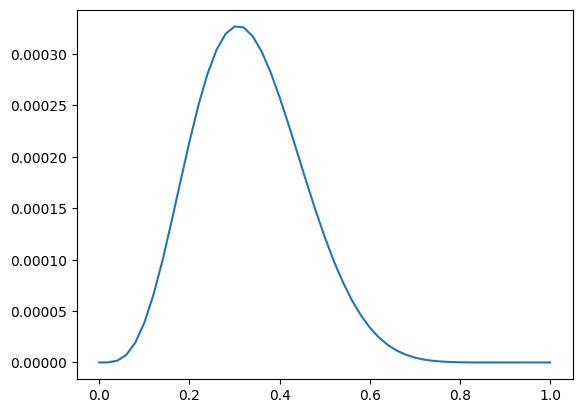

In [30]:
plt.plot(
    thetas,
    veros
)

/tmp/ipython-input-199106429.py:3: RuntimeWarning: divide by zero encountered in log
  np.log(veros)


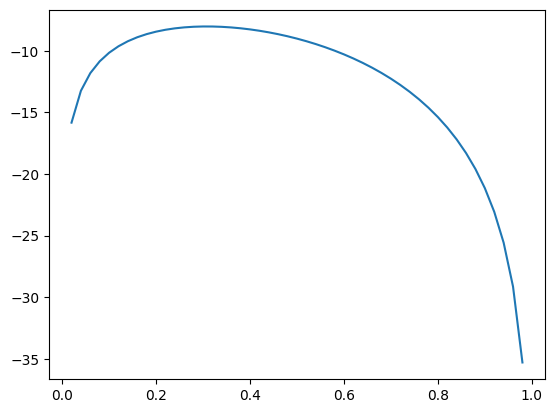

In [31]:
plt.plot(
    thetas,
    np.log(veros)
)

In [37]:
D = [41, 27, 33, 58, 24, 65, 48, 72, 36, 29,
54, 67, 21, 46, 38, 25, 31, 43, 59, 50,
63, 35, 44, 22, 68, 26, 55, 61, 28, 73,
47, 39, 70, 53, 32, 66, 30, 64, 56, 37,
34, 62, 42, 51, 71, 57, 69, 23, 45, 40,
75, 20, 74, 49, 19, 60, 52, 77, 78, 43,
65, 26, 31, 48, 33, 68, 28, 37, 63, 24,
36, 27, 39, 42, 44, 54, 57, 21, 30, 46,
62, 50, 70, 29, 25, 58, 60, 55, 34, 40,
67, 41, 71, 32, 66, 35, 23, 59, 49, 22,
47, 73, 38, 64, 20, 45, 68, 72, 74, 63,
43, 33, 31, 53, 28, 26, 24, 61, 36, 56,
52, 25, 27, 34, 40, 50, 65, 29, 46, 38,
66, 30, 32, 35, 37, 44, 39, 68, 67, 41,
60, 42, 69, 45, 54, 48, 70, 22, 71, 23,
49, 43, 73, 31, 64, 33, 28, 58, 20, 63,
55, 56, 72, 26, 24, 74, 25, 62, 27, 61

]

(array([49., 45., 40., 36.]),
 array([19.  , 33.75, 48.5 , 63.25, 78.  ]),
 <BarContainer object of 4 artists>)

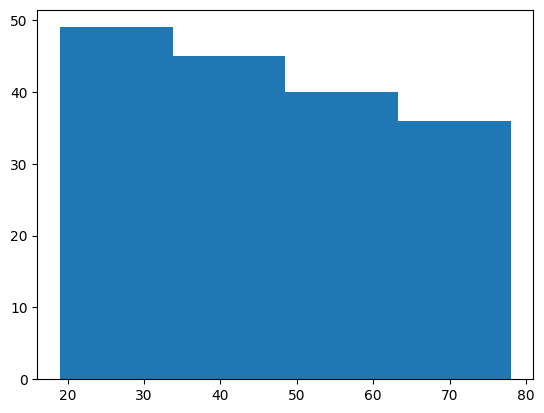

In [38]:
plt.hist(D, bins=4)

In [39]:
import pandas as pd
df = pd.read_csv('http://www.statsci.org/data/oz/dugongs.txt', sep='\t')
df

,Age,Length
0,1.0,1.80
1,1.5,1.85
2,1.5,1.87
3,1.5,1.77
4,2.5,2.02
5,4.0,2.27
6,5.0,2.15
7,5.0,2.26
8,7.0,2.35
9,8.0,2.47


In [72]:
df_synth = pd.DataFrame().assign(
    x = np.random.normal(size=40, loc=10, scale=1)
)
df_synth = df_synth.assign(
    y = 3 * df_synth['x']+ np.random.normal(size=40)
)

<Axes: xlabel='x', ylabel='y'>

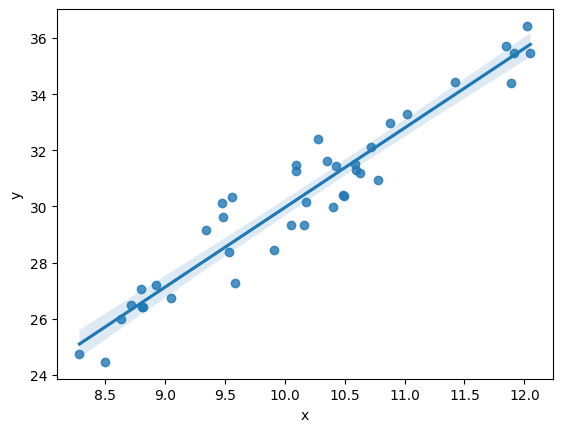

In [73]:
import seaborn as sns
sns.regplot(
    data = df_synth,
    x = 'x',
    y = 'y'
)

In [47]:
from scipy.stats.distributions import norm

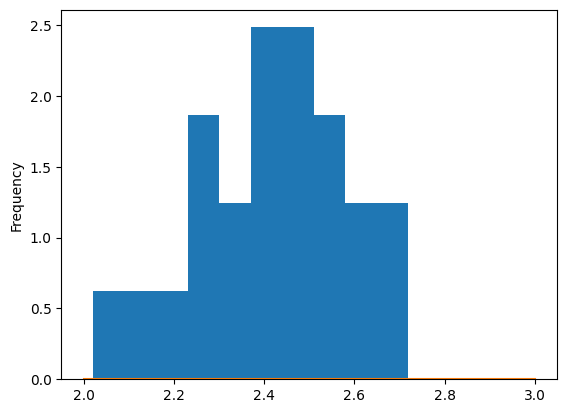

In [51]:
mu = df['Length'][df['Length'] > 2].var()
s = df['Length'][df['Length'] > 2].std(ddof=1)
pdf = norm(mu, s)

df['Length'][df['Length'] > 2].plot.hist(density=True)
plt.plot(
    np.linspace(2, 3),
    pdf.pdf(
        np.linspace(2, 3)
    )
)

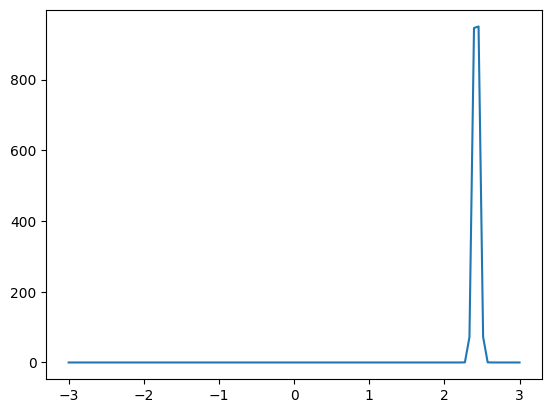

In [60]:
D =df['Length'][df['Length'] > 2]
mus = np.linspace(-3, 3, 100)
veros = []
for mu in mus:
    pdf = norm(mu, s)
    vero = pdf.pdf(D)
    veros.append(vero.prod())
# print(mus, veros)
plt.plot(mus, veros)

In [ ]:
D = []
for i in range(10000):
    D.append(np.random.beta(3, 2, size=500).mean())

In [ ]:
D = [1, 1, 0, 0]
np.std(D, ddof=1)

0.5773502691896257

In [ ]:
np.mean(D)

0.5

In [ ]:
ss.norm(0.5, 0.57).pdf(D).prod()

0.051497937680911085

In [ ]:
pmf(0.5, np.array(D)).prod()

0.0625

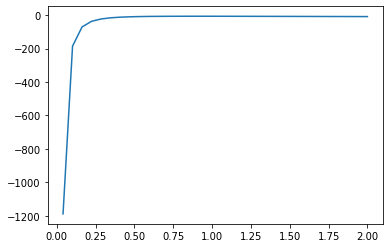

In [ ]:
mus = np.linspace(-3, 3)
sigmas = np.linspace(-1, 2)
veros = []
for sigma in sigmas:
    vero = np.log(ss.norm(2, sigma).pdf(D)).sum()
    veros.append(vero)
plt.plot(
    sigmas,
    veros
)

(array([  11.,  120.,  605., 1585., 2528., 2666., 1685.,  625.,  153.,
          22.]),
 array([0.56767368, 0.57409336, 0.58051303, 0.58693271, 0.59335239,
        0.59977207, 0.60619174, 0.61261142, 0.6190311 , 0.62545078,
        0.63187046]),
 <a list of 10 Patch objects>)

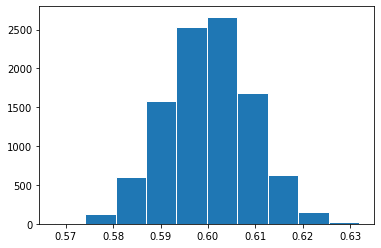

In [ ]:
plt.hist(
    D,
    edgecolor='w'
)

In [ ]:
import scipy.stats as ss

In [ ]:
D = []
for i in range(100):
    D.append(np.random.beta(3, 2, size=500).mean())

In [ ]:
mus = np.linspace(0.4, 0.7)
sigmas = np.linspace(0, 0.1, 200)
melhor = []
melhor_vero = -np.inf
for mu in mus:
    for sigma in sigmas:
        verossimilhanca = np.log(
            ss.norm(
                loc=mu,
                scale=sigma
                ).pdf(D)
        ).sum()
        if verossimilhanca > melhor_vero:
            melhor = [mu, sigma]
            melhor_vero = verossimilhanca

/usr/local/lib/python3.7/dist-packages/scipy/stats/_distn_infrastructure.py:1740: RuntimeWarning: divide by zero encountered in true_divide
  x = np.asarray((x - loc)/scale, dtype=dtyp)
/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:11: RuntimeWarning: divide by zero encountered in log
  # This is added back by InteractiveShellApp.init_path()


In [ ]:
melhor

[0.6020408163265306, 0.009045226130653268]

In [ ]:
np.mean(D), np.std(D, ddof=1)

(0.6001544666245621, 0.008949972997099072)

In [ ]:
sigmas

array([0.        , 0.00050251, 0.00100503, 0.00150754, 0.00201005,
       0.00251256, 0.00301508, 0.00351759, 0.0040201 , 0.00452261,
       0.00502513, 0.00552764, 0.00603015, 0.00653266, 0.00703518,
       0.00753769, 0.0080402 , 0.00854271, 0.00904523, 0.00954774,
       0.01005025, 0.01055276, 0.01105528, 0.01155779, 0.0120603 ,
       0.01256281, 0.01306533, 0.01356784, 0.01407035, 0.01457286,
       0.01507538, 0.01557789, 0.0160804 , 0.01658291, 0.01708543,
       0.01758794, 0.01809045, 0.01859296, 0.01909548, 0.01959799,
       0.0201005 , 0.02060302, 0.02110553, 0.02160804, 0.02211055,
       0.02261307, 0.02311558, 0.02361809, 0.0241206 , 0.02462312,
       0.02512563, 0.02562814, 0.02613065, 0.02663317, 0.02713568,
       0.02763819, 0.0281407 , 0.02864322, 0.02914573, 0.02964824,
       0.03015075, 0.03065327, 0.03115578, 0.03165829, 0.0321608 ,
       0.03266332, 0.03316583, 0.03366834, 0.03417085, 0.03467337,
       0.03517588, 0.03567839, 0.0361809 , 0.03668342, 0.03718